# SENG 474 Assignment 1

In [1]:
# If you are using Google Colab, you can mount your Google Drive to access files stored there. Just replace the file path with the actual path to your file in Google Drive. 
# from google.colab import drive
# drive.mount('/content/drive')
# raw_data =  pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.filetype')

## Imports

To keep things organized please place all imports in the cell below. A few that you will likely use have been included for you.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# student imports
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
med_imputer = SimpleImputer(strategy="median")
# use standardscaler since z-score (standard) normalization isn't sensitive to (extreme) outliers
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

## Part 1 - Initial Data Exploration

In this section you should take an initial look at the dataset and examine it for missing values and/or outliers and determine what should be done to the data to prepare it for your machine learning models.
You should evaluate whether outliers in the data ought to be removed as well as if it is reasonable to remove entries that have missing data or whether imputation might be a better solution. There is no single correct answer as to how you should handle the data, it is up to you to justify the decisions you have made and why you made them in your report.

**Hints:**

Two columns have had gaussian noise added, one columns has NaN values, and some synthetic extreme outliers have been added to the data set. 

Using interquartile range provides a simple method for trimming outliers.

You may even want to perform K-Means clustering on the raw data first to inform your proccessing.

In [3]:
# Use this commented out line if you're trying to run this with a local file:
# raw_data =  pd.read_csv('A1_data.csv', header=None).to_numpy()
# print(raw_data[:5])

raw_data = pd.read_csv('A1_data.csv')
# raw_data.head()

# Find missing data (NaNs)
raw_data.info()
# used to reveal counts of all non-null data compared to number of columns
# raw_data.describe()

print("percentage NaN alcohol values:")
print(raw_data[["alcohol"]].isnull().sum() / len(raw_data))
# revealed that the alcohol column has 18.87% NaN values. This is under 20%, which is generally considered in the range of acceptable imputation

# performing median imputation on alcohol
raw_data_alcohol_num = raw_data[["alcohol"]]
med_imputer.fit(raw_data_alcohol_num)

print("alcohol median:", raw_data_alcohol_num.median())
print(med_imputer.statistics_)

X = med_imputer.transform(raw_data_alcohol_num)
# apply imputed data to raw_data
raw_data["alcohol"] = X
imputed_data = raw_data

# check for nans
print("imputed data info:")
imputed_data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6821 entries, 0 to 6820
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6821 non-null   float64
 1   volatile acidity      6821 non-null   float64
 2   citric acid           6821 non-null   float64
 3   residual sugar        6821 non-null   float64
 4   chlorides             6821 non-null   float64
 5   free sulfur dioxide   6821 non-null   float64
 6   total sulfur dioxide  6821 non-null   float64
 7   density               6821 non-null   float64
 8   pH                    6821 non-null   float64
 9   sulphates             6821 non-null   float64
 10  alcohol               5534 non-null   float64
 11  quality               6821 non-null   int64  
 12  class                 6821 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 692.9 KB
percentage NaN alcohol values:
alcohol    0.188682
dtype: float64
alcohol m

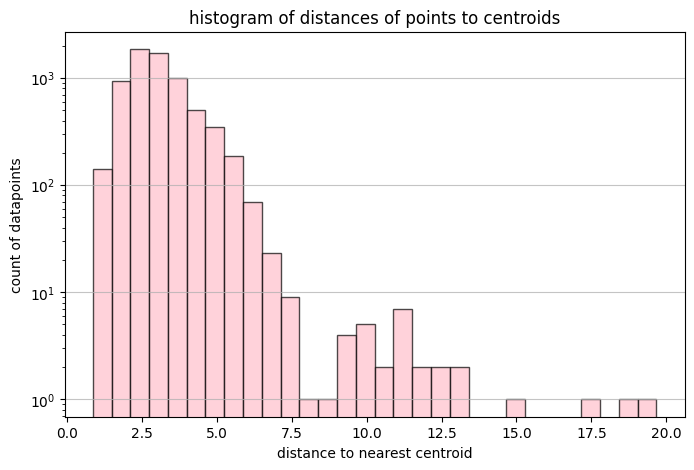

In [4]:
# Visualizing the data (explorative k-means clustering)
# perform k-means clustering
scaled_data = scaler.fit_transform(imputed_data.select_dtypes(include=["number"]))
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
kmeans.fit(scaled_data)

# find distances from each point to nearest centroid to detect outliers
distance = kmeans.transform(scaled_data).min(axis=1)

# plotting distance data to visualize outliers
plt.figure(figsize=(8,5))
plt.hist(distance, bins=30, edgecolor="black", alpha=0.7, color="pink")
plt.xlabel("distance to nearest centroid")
plt.ylabel("count of datapoints")
plt.title("histogram of distances of points to centroids")
plt.grid(axis="y", alpha = 0.75)
# applying a logarithmic yscale since linear scale made outlier columns with small count of datapoints hard to see on plot
plt.yscale("log")
plt.show()


In [5]:

# looks like normal curve until after the 7.5 mark.
# an appropriate cut-off line for outliers would be the 8 mark.

# After initially trying to perform IQR on all columns, and having too many data entries removed for even a very strict IQR multiplier,
# I checked to see if only a couple columns are causing most of the gaussian noise (from the above hint).
for col in imputed_data.select_dtypes(include=["number"]).columns:
    Q1 = imputed_data[col].quantile(0.25)
    Q3 = imputed_data[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((imputed_data[col] < Q1 - 3*IQR) | (imputed_data[col] > Q3 + 3*IQR)).sum()
    if n_outliers > 0.1 * len(imputed_data): print(f"{col}: {n_outliers} outliers")

noisy_cols = ["volatile acidity", "class"]

clean_data = imputed_data.copy()
for col in clean_data.select_dtypes(include=["number"]).columns:
    if col in noisy_cols:
        continue
    Q1 = clean_data[col].quantile(0.25)
    Q3 = clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    clean_data = clean_data[(clean_data[col] >= lower) & (clean_data[col] <= upper)]

print(f"percentage of rows removed: {1 - (len(clean_data) / len(imputed_data))}")

volatile acidity: 1699 outliers
class: 1677 outliers
percentage of rows removed: 0.08605776279137956


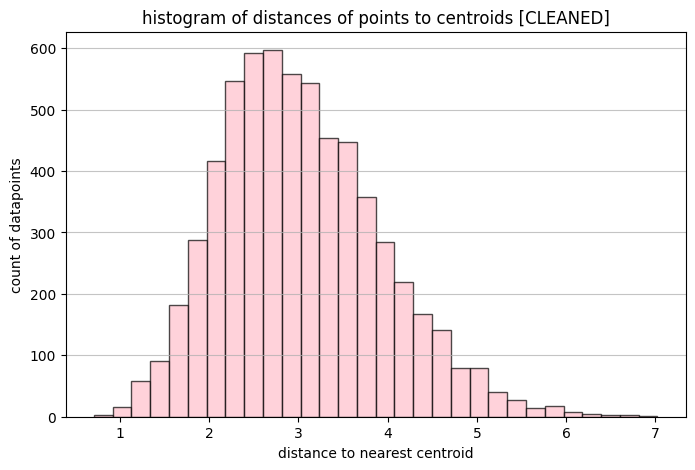

In [6]:
scaled_data = scaler.fit_transform(clean_data.select_dtypes(include=["number"]))
kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')
kmeans.fit(scaled_data)

# find distances from each point to nearest centroid to detect outliers
distance = kmeans.transform(scaled_data).min(axis=1)

# plotting distance data to visualize outliers
plt.figure(figsize=(8,5))
plt.hist(distance, bins=30, edgecolor="black", alpha=0.7, color="pink")
plt.xlabel("distance to nearest centroid")
plt.ylabel("count of datapoints")
plt.title("histogram of distances of points to centroids [CLEANED]")
plt.grid(axis="y", alpha = 0.75)
plt.show()

# alot more normal

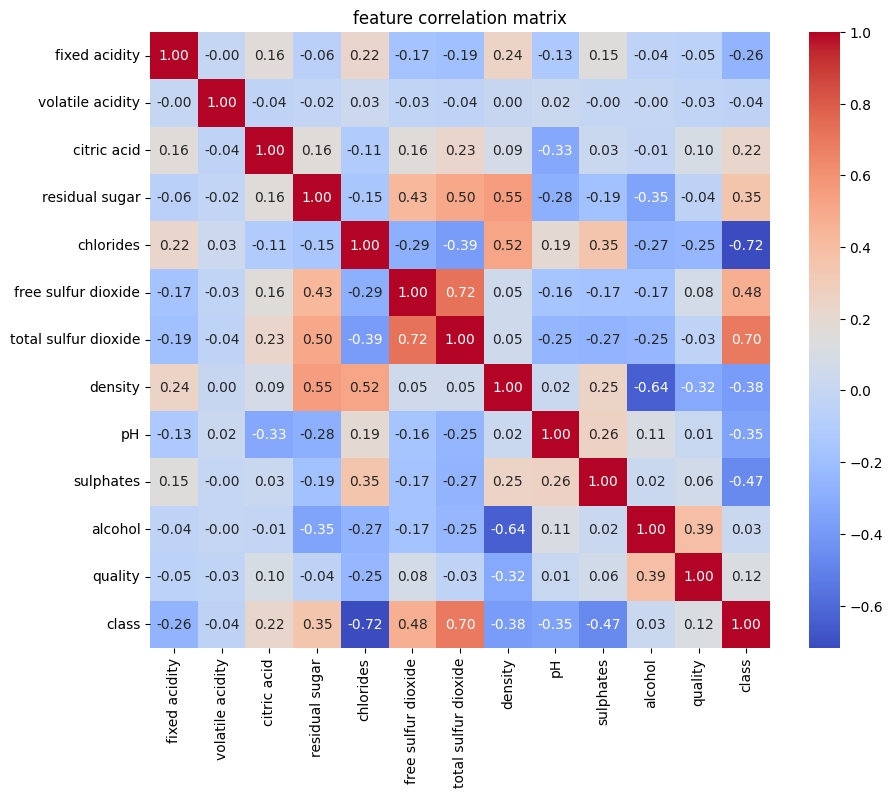

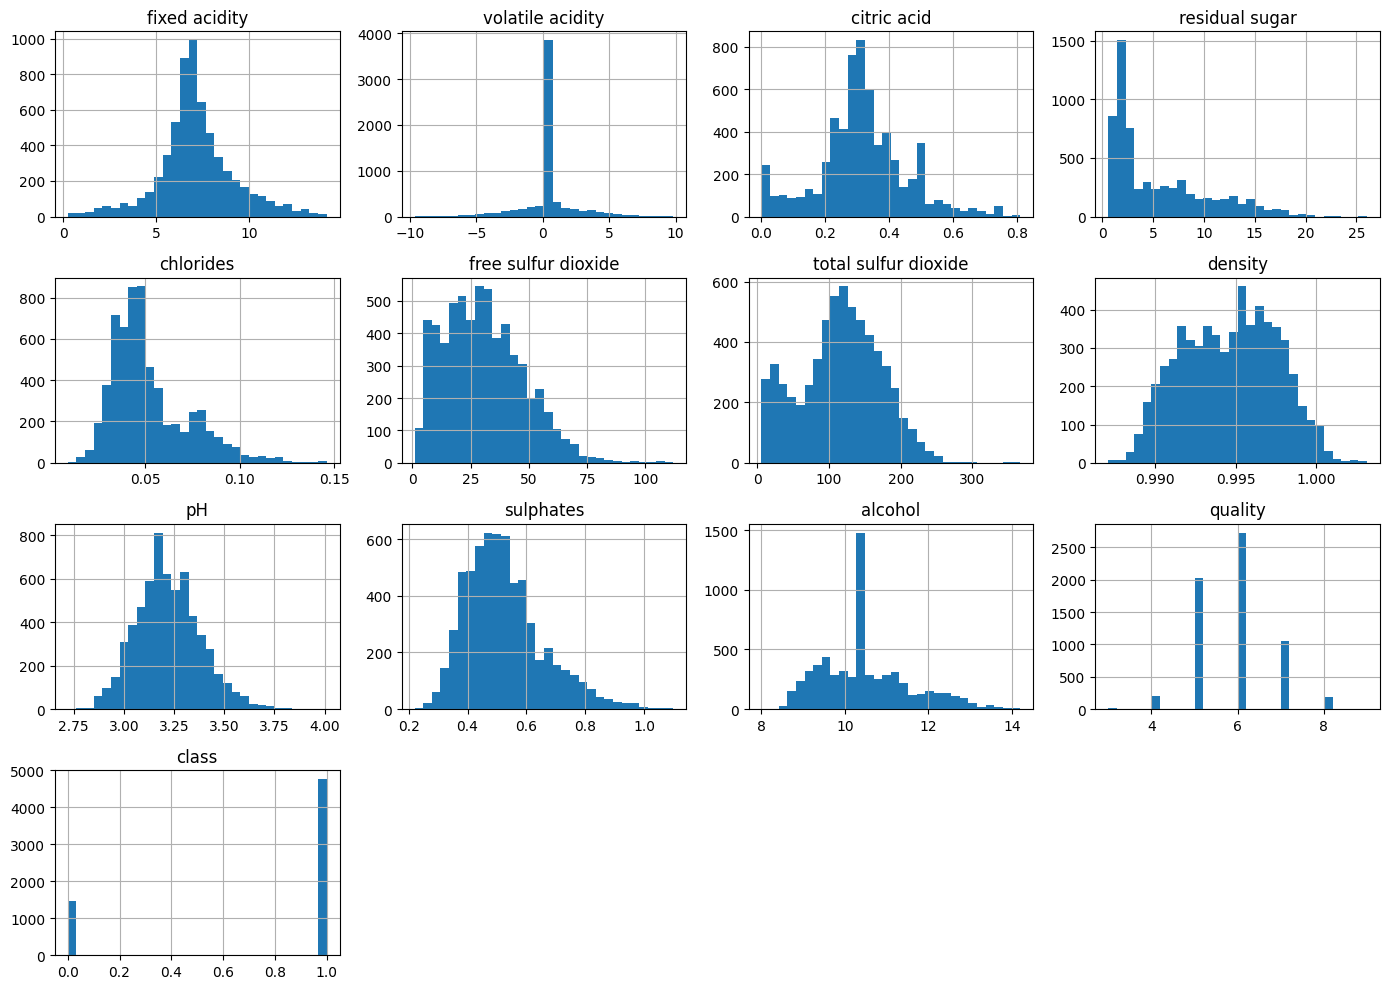

In [7]:

# examining correlations
corr_matrix = clean_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("feature correlation matrix")
plt.show()

# analyzing distribution the data is drawn from
clean_data.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

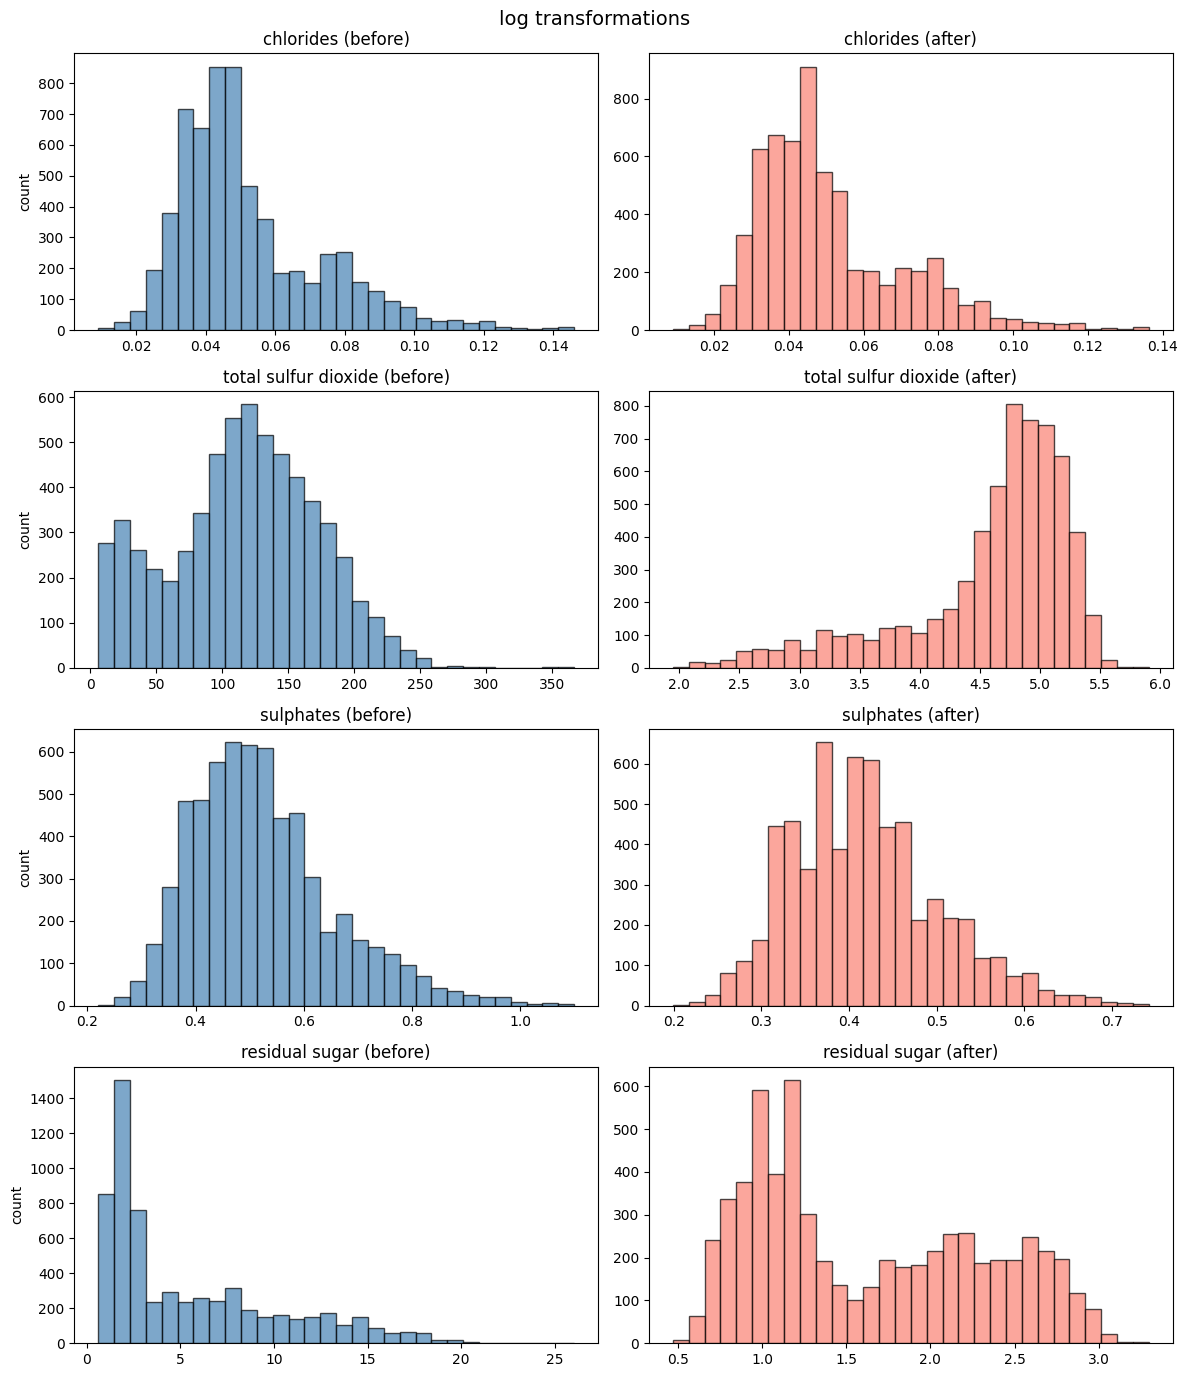

log transforms kept: ['sulphates', 'residual sugar']
log transforms reverted: ['chlorides', 'total sulfur dioxide']


In [ ]:
# chlorides x class, alcohol x density are closely inversely associated 
# total sulfur dioxide x class closely positively associated, free sulfur x total sulfur doixide

# volatile acidity cannot be negative.

# preprocessing data what i feel is right such as imputation, feature transformations, (log or polynoimial transforms_, removing redundant features or outliers from the data.)

# remove volatile acidity. it contains negative values, is noisy, has near-zero correlation with every other feature
# class is noisy as well but informative - strong correlations with chlorides and total sulfur dioxide
clean_data = clean_data.drop(columns=["volatile acidity"])
#drop free sulur dioxide since very similar correlations as total sulfur dioxide, high correlation between them, and total sulfur dioxide has stronger correlation with class + domain knowledge says total sort of measures free anyways
clean_data = clean_data.drop(columns=["free sulfur dioxide"])

# log transformations on right skewed data
log_cols = ["chlorides", "total sulfur dioxide", "sulphates", "residual sugar"]
keep_log_cols = ["sulphates", "residual sugar"]
# revert these two log transforms because I found log transform worsened the data
revert_cols = ["chlorides", "total sulfur dioxide"]

fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, 14))
fig.suptitle("log transformations", fontsize=14)

for i, col in enumerate(log_cols):
    axes[i, 0].hist(clean_data[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    axes[i, 0].set_title(f"{col} (before)")
    axes[i, 0].set_ylabel("count")

    clean_data[col] = np.log1p(clean_data[col])

    axes[i, 1].hist(clean_data[col], bins=30, color="salmon", edgecolor="black", alpha=0.7)
    axes[i, 1].set_title(f"{col} (after)")

plt.tight_layout()
plt.show()

# revert columns where log transform did not improve distribution
for col in revert_cols:
    clean_data[col] = np.expm1(clean_data[col])

print(f"log transforms kept: {keep_log_cols}")
print(f"log transforms reverted: {revert_cols}")

# TODO: make axes the same so values are comparable

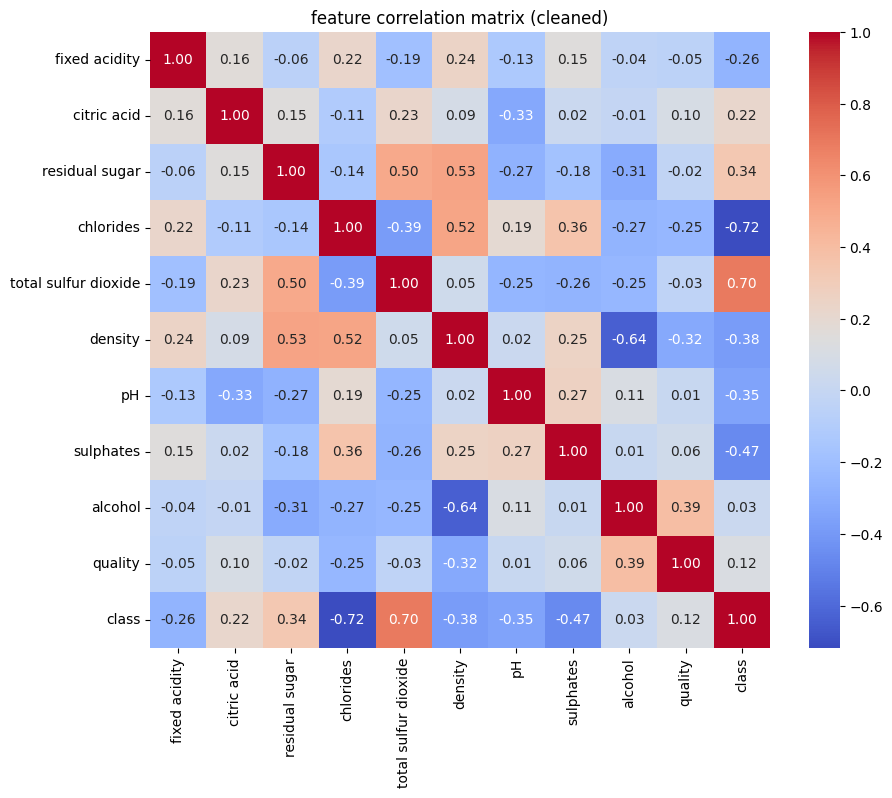

In [9]:
# final correlation matrix after all preprocessing
corr_matrix = clean_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("feature correlation matrix (cleaned)")
plt.show()

## Part 2 - Preparing the Data

When dividing your data into training, validation (assuming you do not use K-fold cross validation), and test sets it is import to ensure the same samples are used for training in all of your models. A good way to ensure that you have done this correctly is to check that your regression and classification training and testing data sets match after being prepared. You also should make sure that the shape of your training/testing sets make sense. For example, your training data array might have a shape of (num_samples_in_train, 11) since there are 11 features in the data set, and your regression and class label arrays would have a shape of (num_samples_in_train, ) representing that it is just a 1D array with a value for each training sample.

**Hint:** It is common to perform Min-Max scaling on the data so that your features take values between 0 and 1 (instead of using $x \in \mathcal{R}^d$ you may use $x \in [0,1]^d$).

In [10]:
# Normalize Data
MinMaxScaler()

# Shuffle the rows of the data

# Split into features and labels

# Split into training and testing sets ensuring that the same samples are used for both regression and classification tasks

# Check the shapes of the resulting datasets to ensure they are correct

,feature_range,"(0, ...)"
,copy,True
,clip,False


The above assumes that students will use k-fold cross validation and thus a validation set is not explicitly needed.

## Part 3/4 - See PDF for details

Please put any methods you will use for your personal implementations here. Clearly label the code for each model you implement with a markdown sub-heading. "### Subheading"

A template of an sklearn model is provided for you. You will need to specify the model parameters, replace the fit method with the appropriate learning algorithm, and replace the predict function to output the prediction of your model on some input data.

I suggest you attempt the majority of the assignment first using the provided models from sklearn and then go back and try to replace them with your own implementations. 

### Self Implemented Model 1

In [11]:
# https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html
class MyEstimator(BaseEstimator):

    def __init__(self, *, param=1):
        self.param = param

    def fit(self, X, y=None):
        
        # In a real estimator, you would typically use X and y to learn from the data. For this example, we will just modify the parameter to demonstrate the functionality.
        self.param = self.param + 1
        
        # Set the is_fitted_ attribute to True to indicate that the estimator has been fitted.
        self.is_fitted_ = True
        return self
    
    def predict(self, X):

        # In a real estimator, you would use the learned parameters to make predictions based on the input data X. For this example, we will just return an array of the same shape as X with all values set to the current value of self.param.
        return np.full(shape=X.shape[0], fill_value=self.param)
    
    def score(self, X, y):

        # In a real estimator, you would typically compare the predicted values with the true labels y to compute a performance metric. For this example, we will just return the mean accuracy of the predictions.
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [12]:
# Example usage of the MyEstimator class
estimator = MyEstimator(param=2)
print(estimator.get_params())

X = np.array([[1, 2], [2, 3], [3, 4]])
y = np.array([1, 0, 1])

estimator.fit(X, y).predict(X)
estimator.set_params(param=3).fit(X, y)

print(estimator.predict(X))
print(estimator.score(X, y))

{'param': 2}
[4 4 4]
0.0


### Self Implemented Model 2

In [13]:
# https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html
class MyEstimator(BaseEstimator):

    def __init__(self, *, param=1):
        self.param = param

    def fit(self, X, y=None):
        
        # In a real estimator, you would typically use X and y to learn from the data. For this example, we will just modify the parameter to demonstrate the functionality.
        self.param = self.param + 1
        
        # Set the is_fitted_ attribute to True to indicate that the estimator has been fitted.
        self.is_fitted_ = True
        return self
    
    def predict(self, X):

        # In a real estimator, you would use the learned parameters to make predictions based on the input data X. For this example, we will just return an array of the same shape as X with all values set to the current value of self.param.
        return np.full(shape=X.shape[0], fill_value=self.param)
    
    def score(self, X, y):

        # In a real estimator, you would typically compare the predicted values with the true labels y to compute a performance metric. For this example, we will just return the mean accuracy of the predictions.
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

### K-Fold Cross-Validation

In [14]:
# This function assumes the data is already pre-proccessed via scaling and row-wise shuffled
# It returns the average score of the model on the training and validation sets as a tuple 
def k_fold_cross_validation(data, k, model):


    # Return the average training and validation scores across all folds
    return (0, 0)

## Part 6 - Model Evaluation / Hyper-Parameter Tuning

For each model you will need to perform 2 experiments in which you vary a single hyper-parameter and keep all others fixed. 
For each experiment create a plot of the model's training and validation error. 
In total you will conduct 8 experiments. 

### Regression Model

### Classification Model

### Unsupervised Learning Model (K-Means Clustering)

### Additional Regression or Classification Model

## Part 7 - Model Evaluation on the Test Set

### Regression Model

### Classification Model

### Unsupervised Learning Model (K-Means Clustering)

### Additional Regression or Classification Model